# EDA_2nd — 전처리 파이프라인

**데이터**: `df_ffill_2007.csv` (EDA_1st 산출물, 2007~, 4820행, 13컬럼)  
**컬럼**: OilPrice, RealInterestRate, CPI, DollarIndex, VIX, IndustryProduction, CPE, OilInventories, OPECProduction, OilProduction, TermSpread, TreasuryYield, FedFundsRate

| 단계 | 내용 |
|------|------|
| 1 | 단위근 검정 - ADF 검정 |
| 2 | 다중공선성 검토 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (날짜 인덱스 포함) ──────────────────────────
DATA_PATH = '../data/Finance_Final/EDA_1st_result.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'], index_col='date')

print(f'Shape  : {df.shape}')
print(f'기간   : {df.index.min().date()} ~ {df.index.max().date()}')
print(f'컬럼   : {df.columns.tolist()}')
print(f'\n결측치: \n{df.isnull().sum()}')
print(f'\n기초 통계량:')
display(df.describe().round(3))

Shape  : (4820, 13)
기간   : 2007-01-02 ~ 2026-03-16
컬럼   : ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TermSpread', 'TreasuryYield', 'FedFundsRate']

결측치: 
OilPrice              0
RealInterestRate      0
CPI                   0
DollarIndex           0
VIX                   0
IndustryProduction    0
CPE                   0
OilInventories        0
OPECProduction        0
OilProduction         0
TermSpread            0
TreasuryYield         0
FedFundsRate          0
dtype: int64

기초 통계량:


,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TermSpread,TreasuryYield,FedFundsRate
count,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000,4820.000
mean,72.615,0.859,251.783,106.527,19.803,98.726,13221.850,399014.624,33888.576,9147.961,1.052,2.820,1.582
std,21.710,0.670,34.531,12.501,8.777,4.299,1757.414,67604.860,1762.693,2974.100,0.953,1.064,1.891
min,-36.980,-0.407,203.437,85.469,9.140,84.562,11068.000,265361.000,26934.937,3839.000,-1.080,0.520,0.050
25%,56.118,0.395,226.750,93.554,14.020,97.666,11555.700,335194.750,33012.167,5722.000,0.270,1.990,0.120
50%,71.675,0.729,240.222,110.582,17.465,100.161,12891.200,418971.000,33849.792,9199.000,1.020,2.700,0.380
75%,89.000,1.387,268.383,116.830,22.755,101.428,14796.000,448539.000,34953.451,12000.000,1.760,3.730,2.420
max,145.310,2.374,327.460,130.041,82.690,104.100,16700.200,540722.000,37192.168,13862.000,2.910,5.260,5.330


## 1. 단위근 검정
### Step 1. ADF 단위근 검정 (Augmented Dickey-Fuller)

각 컬럼에 대해 ADF 검정을 수행하여 정상성(stationarity) 여부를 판단합니다.  
- **귀무가설 H₀**: 단위근 존재 (비정상 시계열)  
- **기각 기준**: p-value < 0.05 → 정상 시계열  
- 비정상으로 판정된 컬럼에는 1차 차분을 적용합니다.

In [2]:
# ── ADF 검정 함수 ─────────────────────────────────────────
def run_adf(series, col_name, alpha=0.05):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    stationary = pval < alpha
    return {
        'Column'    : col_name,
        'ADF Stat'  : round(stat, 4),
        'p-value'   : round(pval, 4),
        'Lags Used' : lags,
        'Obs'       : nobs,
        'Crit 1%'   : round(crit['1%'], 3),
        'Crit 5%'   : round(crit['5%'], 3),
        'Crit 10%'  : round(crit['10%'], 3),
        'Stationary': stationary,
    }

# ── 전체 컬럼 ADF 검정 ────────────────────────────────────
adf_results = [run_adf(df[col], col) for col in df.columns]
adf_df = pd.DataFrame(adf_results).set_index('Column')

# ── 결과 출력 ─────────────────────────────────────────────
print("=" * 70)
print("ADF 검정 결과 (alpha=0.05)")
print("=" * 70)
display(adf_df.style
    .applymap(lambda v: 'background-color: #d4edda' if v is True  else
                        'background-color: #f8d7da' if v is False else '',
              subset=['Stationary'])
    .format({'ADF Stat': '{:.4f}', 'p-value': '{:.4f}',
             'Crit 1%': '{:.3f}', 'Crit 5%': '{:.3f}', 'Crit 10%': '{:.3f}'})
)

non_stationary_cols = adf_df[adf_df['Stationary'] == False].index.tolist()
stationary_cols     = adf_df[adf_df['Stationary'] == True].index.tolist()

print(f"\n정상 시계열     ({len(stationary_cols)}개): {stationary_cols}")
print(f"비정상 시계열   ({len(non_stationary_cols)}개): {non_stationary_cols}")

ADF 검정 결과 (alpha=0.05)


,ADF Stat,p-value,Lags Used,Obs,Crit 1%,Crit 5%,Crit 10%,Stationary
Column,,,,,,,,
OilPrice,-3.1241,0.0248,29,4790,-3.432,-2.862,-2.567,True
RealInterestRate,-2.5407,0.1059,0,4819,-3.432,-2.862,-2.567,False
CPI,1.9933,0.9987,24,4795,-3.432,-2.862,-2.567,False
DollarIndex,-1.0672,0.7280,30,4789,-3.432,-2.862,-2.567,False
VIX,-5.6663,0.0000,10,4809,-3.432,-2.862,-2.567,True
IndustryProduction,-2.6349,0.0860,22,4797,-3.432,-2.862,-2.567,False
CPE,0.0928,0.9656,23,4796,-3.432,-2.862,-2.567,False
OilInventories,-2.1627,0.2201,20,4799,-3.432,-2.862,-2.567,False
OPECProduction,-2.5588,0.1018,22,4797,-3.432,-2.862,-2.567,False



정상 시계열     (2개): ['OilPrice', 'VIX']
비정상 시계열   (11개): ['RealInterestRate', 'CPI', 'DollarIndex', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TermSpread', 'TreasuryYield', 'FedFundsRate']


### Step 2. 비정상 시계열 — 1차 차분 적용

비정상으로 판정된 컬럼에 1차 차분(`diff(1)`)을 적용하고,  
정상 컬럼은 원본 값을 그대로 유지하여 `df_diff` 데이터프레임을 생성합니다.

원본 shape : (4820, 13)
차분 후    : (4819, 13)

차분 적용 컬럼 (11개): ['RealInterestRate', 'CPI', 'DollarIndex', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TermSpread', 'TreasuryYield', 'FedFundsRate']
원본 유지  컬럼 (2개): ['OilPrice', 'VIX']


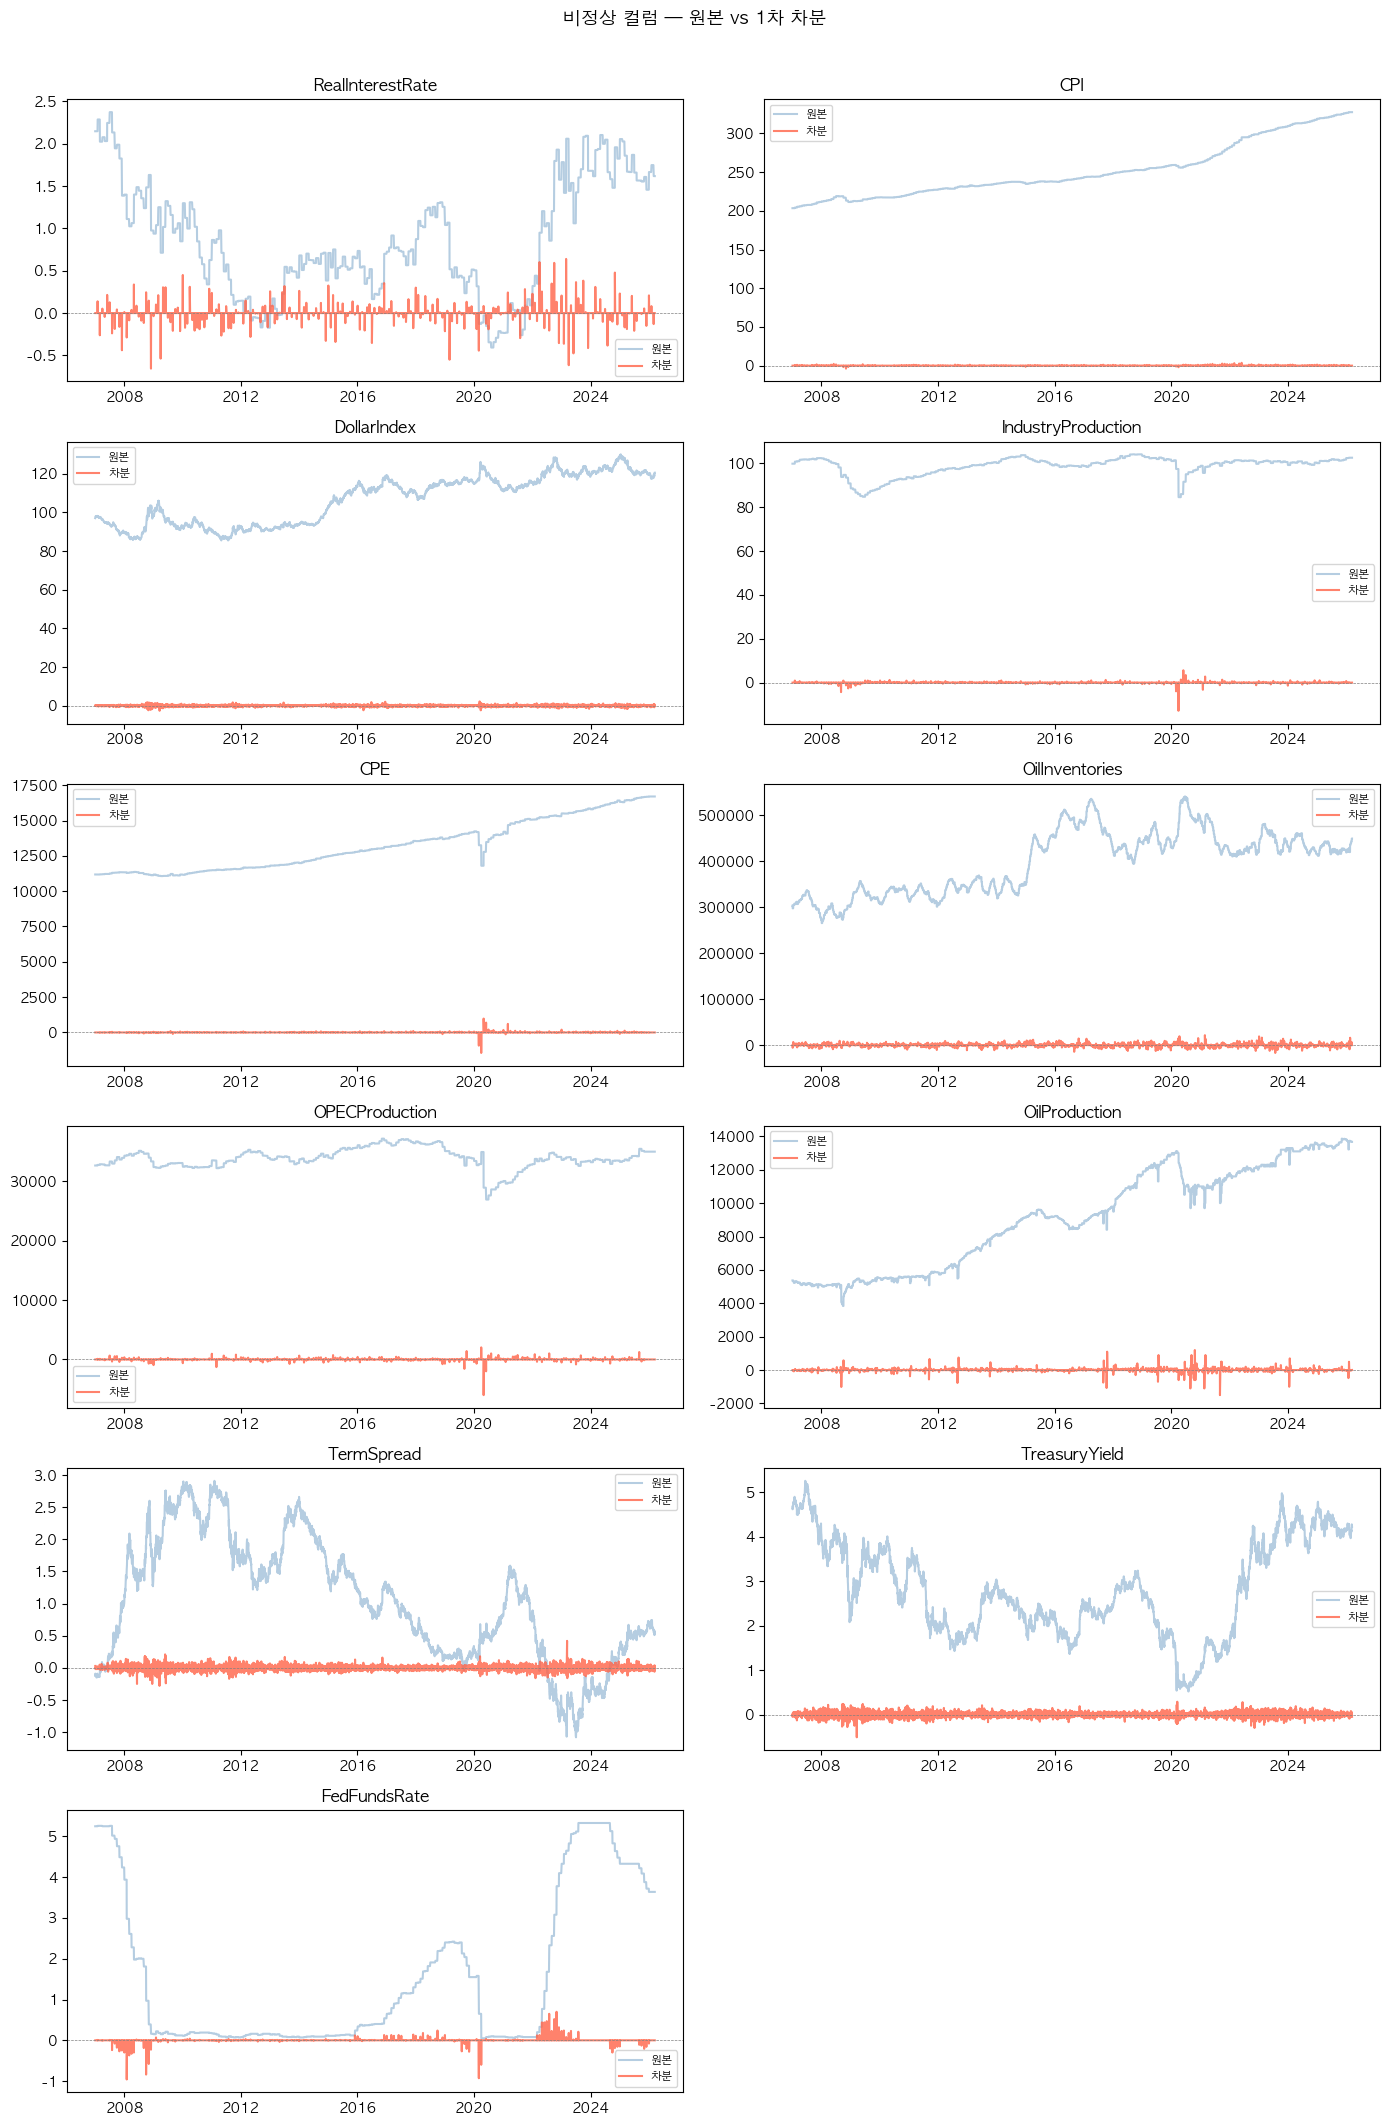

In [3]:
# ── 비정상 컬럼 차분 + 정상 컬럼 원본 유지 ──────────────────
df_diff = df.copy()

for col in non_stationary_cols:
    df_diff[col] = df[col].diff(1)

# 차분으로 생긴 첫 행 NaN 제거
df_diff.dropna(inplace=True)

print(f"원본 shape : {df.shape}")
print(f"차분 후    : {df_diff.shape}")
print(f"\n차분 적용 컬럼 ({len(non_stationary_cols)}개): {non_stationary_cols}")
print(f"원본 유지  컬럼 ({len(stationary_cols)}개): {stationary_cols}")

# ── 차분 전·후 시각화 ─────────────────────────────────────
if non_stationary_cols:
    ncols = 2
    nrows = -(-len(non_stationary_cols) // ncols)      # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

    for ax, col in zip(axes, non_stationary_cols):
        ax.plot(df.index, df[col], alpha=0.4, label='원본', color='steelblue')
        ax.plot(df_diff.index, df_diff[col], alpha=0.8, label='차분', color='tomato')
        ax.set_title(col)
        ax.legend(fontsize=8)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    for ax in axes[len(non_stationary_cols):]:
        ax.set_visible(False)

    plt.suptitle('비정상 컬럼 — 원본 vs 1차 차분', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

### Step 3. 차분 후 ADF 재검정

1차 차분 후에도 비정상으로 남은 컬럼이 있는지 확인합니다.  
여전히 비정상이면 2차 차분이 필요하지만, 대부분의 경제 시계열은 I(1) 과정이므로 1차 차분으로 정상화됩니다.

In [4]:
# ── 차분 후 ADF 재검정 ────────────────────────────────────
adf_diff_results = [run_adf(df_diff[col], col) for col in df_diff.columns]
adf_diff_df = pd.DataFrame(adf_diff_results).set_index('Column')

print("=" * 70)
print("ADF 재검정 결과 — 차분 후 df_diff (alpha=0.05)")
print("=" * 70)
display(adf_diff_df.style
    .applymap(lambda v: 'background-color: #d4edda' if v is True  else
                        'background-color: #f8d7da' if v is False else '',
              subset=['Stationary'])
    .format({'ADF Stat': '{:.4f}', 'p-value': '{:.4f}',
             'Crit 1%': '{:.3f}', 'Crit 5%': '{:.3f}', 'Crit 10%': '{:.3f}'})
)

still_non_stationary = adf_diff_df[adf_diff_df['Stationary'] == False].index.tolist()

if still_non_stationary:
    print(f"\n⚠ 차분 후에도 비정상: {still_non_stationary} → 2차 차분 또는 로그 변환 검토 필요")
else:
    print("\n✓ 차분 후 모든 컬럼이 정상 시계열로 변환되었습니다.")

# ── 최종 요약 ─────────────────────────────────────────────
summary = pd.DataFrame({
    '원본 정상성'   : adf_df['Stationary'],
    '차분 후 정상성': adf_diff_df['Stationary'],
    '처리'         : ['1차 차분' if c in non_stationary_cols else '원본 유지'
                      for c in df_diff.columns],
})
print("\n── 처리 요약 ──")
display(summary)

ADF 재검정 결과 — 차분 후 df_diff (alpha=0.05)


,ADF Stat,p-value,Lags Used,Obs,Crit 1%,Crit 5%,Crit 10%,Stationary
Column,,,,,,,,
OilPrice,-3.1275,0.0246,29,4789,-3.432,-2.862,-2.567,True
RealInterestRate,-69.3978,0.0000,0,4818,-3.432,-2.862,-2.567,True
CPI,-7.9758,0.0000,23,4795,-3.432,-2.862,-2.567,True
DollarIndex,-11.2233,0.0000,29,4789,-3.432,-2.862,-2.567,True
VIX,-5.6649,0.0000,10,4808,-3.432,-2.862,-2.567,True
IndustryProduction,-11.8572,0.0000,21,4797,-3.432,-2.862,-2.567,True
CPE,-12.5962,0.0000,22,4796,-3.432,-2.862,-2.567,True
OilInventories,-10.8362,0.0000,32,4786,-3.432,-2.862,-2.567,True
OPECProduction,-14.7708,0.0000,21,4797,-3.432,-2.862,-2.567,True



✓ 차분 후 모든 컬럼이 정상 시계열로 변환되었습니다.

── 처리 요약 ──


,원본 정상성,차분 후 정상성,처리
Column,,,
OilPrice,True,True,원본 유지
RealInterestRate,False,True,1차 차분
CPI,False,True,1차 차분
DollarIndex,False,True,1차 차분
VIX,True,True,원본 유지
IndustryProduction,False,True,1차 차분
CPE,False,True,1차 차분
OilInventories,False,True,1차 차분
OPECProduction,False,True,1차 차분


## 2. 다중공선성 검토
### Step 4. VIF (Variance Inflation Factor)

차분 후 `df_diff`를 기준으로 각 변수의 다중공선성을 VIF로 측정합니다.

- **VIF = 1**: 다중공선성 없음  
- **1 < VIF < 5**: 낮은 수준 — 양호  
- **5 ≤ VIF < 10**: 중간 수준 — 주의 필요  
- **VIF ≥ 10**: 심각한 다중공선성 — 변수 제거/결합 권장

  VIF (Variance Inflation Factor) — df_diff 기준


Column,VIF,판정
OilPrice,4.0292,✅ 양호 (<5)
VIX,4.0278,✅ 양호 (<5)
CPE,3.3865,✅ 양호 (<5)
IndustryProduction,2.5198,✅ 양호 (<5)
OPECProduction,1.5029,✅ 양호 (<5)
TermSpread,1.3287,✅ 양호 (<5)
TreasuryYield,1.3263,✅ 양호 (<5)
CPI,1.2305,✅ 양호 (<5)
FedFundsRate,1.1665,✅ 양호 (<5)
RealInterestRate,1.0291,✅ 양호 (<5)



심각 (VIF≥10) 0개: []
주의 (5≤VIF<10) 0개: []
양호 (VIF<5)   13개: ['OilPrice', 'VIX', 'CPE', 'IndustryProduction', 'OPECProduction', 'TermSpread', 'TreasuryYield', 'CPI', 'FedFundsRate', 'RealInterestRate', 'OilInventories', 'DollarIndex', 'OilProduction']


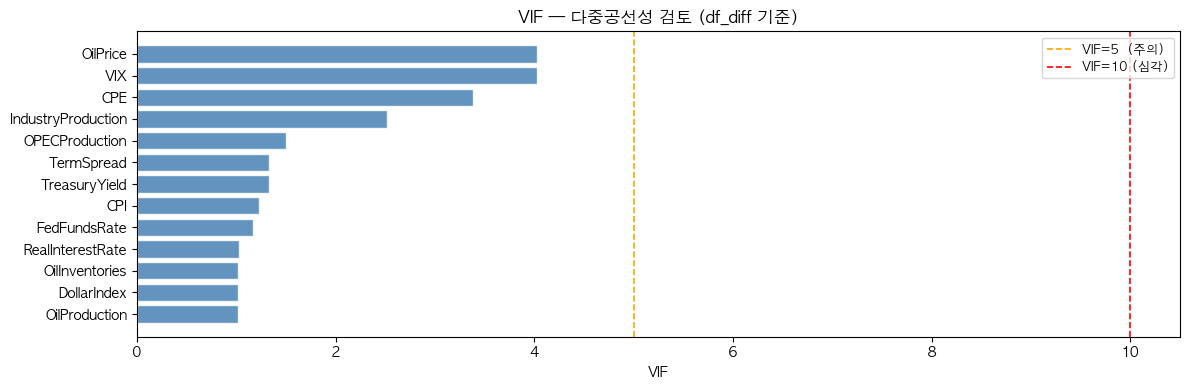

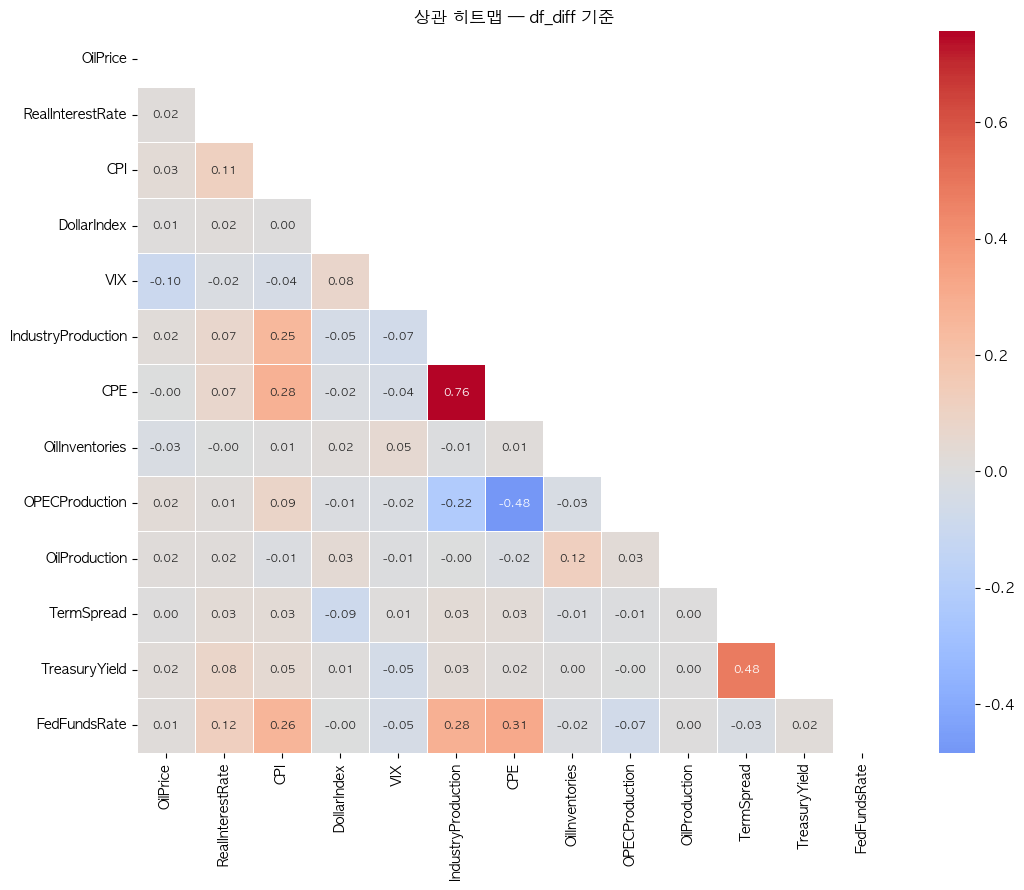

In [5]:
# ── VIF 계산 ──────────────────────────────────────────────
X = df_diff.dropna()
X_vals = X.values

vif_df = pd.DataFrame({
    'Column': X.columns,
    'VIF'   : [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_label(v):
    if v >= 10: return '⚠️  심각 (≥10)'
    elif v >= 5: return '⚡  주의 (5~10)'
    else:        return '✅  양호 (<5)'

vif_df['판정'] = vif_df['VIF'].apply(vif_label)

# ── 결과 출력 ─────────────────────────────────────────────
print('=' * 52)
print('  VIF (Variance Inflation Factor) — df_diff 기준')
print('=' * 52)
display(vif_df.style
    .applymap(lambda v: 'background-color: #f8d7da' if '심각' in str(v) else
                        'background-color: #fff3cd' if '주의' in str(v) else
                        'background-color: #d4edda' if '양호' in str(v) else '',
              subset=['판정'])
    .format({'VIF': '{:.4f}'})
    .hide(axis='index')
)

serious = vif_df[vif_df['VIF'] >= 10]['Column'].tolist()
caution = vif_df[(vif_df['VIF'] >= 5) & (vif_df['VIF'] < 10)]['Column'].tolist()
good    = vif_df[vif_df['VIF'] < 5]['Column'].tolist()

print(f"\n심각 (VIF≥10) {len(serious)}개: {serious}")
print(f"주의 (5≤VIF<10) {len(caution)}개: {caution}")
print(f"양호 (VIF<5)   {len(good)}개: {good}")

# ── 시각화: VIF 막대 그래프 ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['tomato' if v >= 10 else 'gold' if v >= 5 else 'steelblue'
          for v in vif_df['VIF']]
bars = ax.barh(vif_df['Column'], vif_df['VIF'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF=5  (주의)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF=10 (심각)')
ax.set_xlabel('VIF')
ax.set_title('VIF — 다중공선성 검토 (df_diff 기준)')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 상관 히트맵 ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
corr = df_diff.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('상관 히트맵 — df_diff 기준', fontsize=12)
plt.tight_layout()
plt.show()